# Gene-wise vs genome-wise rates

`UniformRates` is **gene-wise**: the total duplication/transfer/loss rate scales with the
number of gene copies, so a family's size follows an exponential birth–death.
`GenomeWiseRates` fires each event at a **constant per-genome rate**, so growth is
*linear* — far less prone to blow-ups. Both run through the same simulator; only the rate
model differs.

In [1]:
import sys, pathlib
for cand in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]:
    if (cand / "zombi2" / "__init__.py").exists():
        sys.path.insert(0, str(cand)); break
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import zombi2 as z
print("zombi2", z.__version__)

zombi2 0.2.0.dev0


## Same tree, two rate models

In [2]:
tree = z.simulate_species_tree(z.BirthDeath(1.0, 0.1), n_tips=25, age=5.0, seed=1)

gene_wise   = z.simulate_genomes(tree, z.UniformRates(duplication=0.25, transfer=0.1,
                                 loss=0.2, origination=0.4), initial_families=30, seed=7)
genome_wise = z.simulate_genomes(tree, z.GenomeWiseRates(duplication=1.0, transfer=0.4,
                                 loss=0.8, origination=0.4), initial_families=30, seed=7)

for name, g in [("gene-wise (UniformRates)", gene_wise),
                ("genome-wise (GenomeWiseRates)", genome_wise)]:
    m = g.profiles.matrix
    print(f"{name:32s} families={len(g.profiles.families):3d}  "
          f"max copies={m.max():3d}  mean copies/present={m[m>0].mean():.2f}")

gene-wise (UniformRates)         families= 39  max copies= 22  mean copies/present=3.53
genome-wise (GenomeWiseRates)    families= 37  max copies=  4  mean copies/present=1.22


## Copy-number distributions

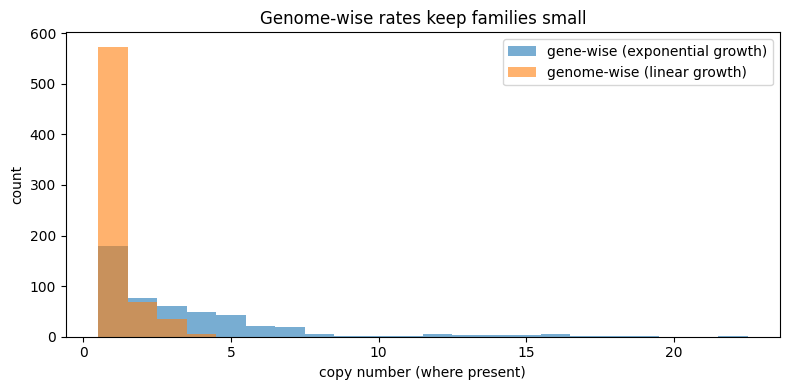

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
gw = gene_wise.profiles.matrix; gw = gw[gw > 0]
nw = genome_wise.profiles.matrix; nw = nw[nw > 0]
bins = range(1, max(gw.max(), nw.max()) + 2)
ax.hist(gw, bins=bins, align="left", alpha=0.6, label="gene-wise (exponential growth)")
ax.hist(nw, bins=bins, align="left", alpha=0.6, label="genome-wise (linear growth)")
ax.set_xlabel("copy number (where present)"); ax.set_ylabel("count"); ax.legend()
ax.set_title("Genome-wise rates keep families small")
plt.tight_layout(); plt.show()

## Why the difference?

Under **gene-wise** rates the duplication rate of a family is `d · (copies)`, so once a
family has several copies it duplicates faster — an exponential feedback. Under
**genome-wise** rates the whole genome duplicates *something* at rate `d` regardless of
size, so a given family accrues copies only linearly. That makes genome-wise models
naturally bounded; gene-wise models usually want a
[growth cap](https://github.com/AADavin/zombi2/blob/main/docs/guide/growth.md)
(`max_family_size`) or a `carrying_capacity`.

Both are just `RateModel` subclasses feeding the *same* engine — see
`docs/guide/extending.md`.